<h1 style="margin-bottom: 0;">Nuestra Actual Realidad.</h1> <h4 style="margin-top: 0; margin-bottom: 0; font-size: 1.3em; font-weight: normal;"> Como país enfrentamos una de las más duras etapas económicas antes vividas por los cubanos. Y aunque no es una novedad lo difícil que puede llegar a ser vivir de un salario, nunca antes fue un desafío enorme adquirir productos básicos que necesitamos en nuestro día a día, para cocinar, asearnos o lavar nuestra ropa. </h4> <h4 style="margin-top: 0; margin-bottom: 0; font-size: 1.3em; font-weight: normal;"> En este contexto de crisis, las MIPYMES (Micro, Pequeñas y Medianas Empresas) han emergido como un actor económico fundamental pero controversial. Legalizadas desde 2021, estas empresas privadas representan una alternativa al sector estatal, ofreciendo productos que frecuentemente desaparecen de los mercados oficiales. Sin embargo, sus precios, determinados por los altísimos costos de producción, la dependencia de importaciones en divisas y la hiperinflación,han hecho que sus artículos resulten casi inaccesibles para quienes dependen únicamente de salarios en pesos cubanos.</h4> <h4 style="margin-top: 0; margin-bottom: 0; font-size: 1.3em; font-weight: normal;"> Esta realidad se nutre de múltiples factores: salarios que no alcanzan, tiendas estatales que solo aceptan divisas, y una moneda nacional cuyo valor en el mercado informal se desploma día a día. Frente a esto, el Estado cubano busca soluciones en un escenario complejo, marcado por las presiones externas y una abrumadora deuda. Para la familia cubana, el resultado es el mismo: llegar a fin de mes se convierte en una hazaña cada vez más difícil.</h4>

<h2 style="margin-bottom: 0;">¿Qué tan difícil será hallar los más básicos y necesarios de los productos en las MIPYMES?</h2> <h4 style="margin-top: 0; margin-bottom: 0; font-size: 1.3em; font-weight: normal;"> Los siguientes análisis están basados en 9 productos alimenticios que, tras investigar, son indispensables en nuestra vida, ya que requerimos como seres humanos de proteína animal, legumbres, lácteos y carbohidratos. Pero también se analizan otros 3 productos necesarios para la higiene, aspecto fundamental en la vida del hombre.</h4> <h4 style="margin-top: 0; margin-bottom: 0; font-size: 1.3em; font-weight: normal;"> Sería normal preguntarse, ¿qué tan accesibles son estos productos en las MIPYMES? La gráfica a continuación muestra los resultados tras analizar la disponibilidad de estos 12 productos en 30 MIPYMES ubicadas en diferentes municipios de La Habana.</h4>

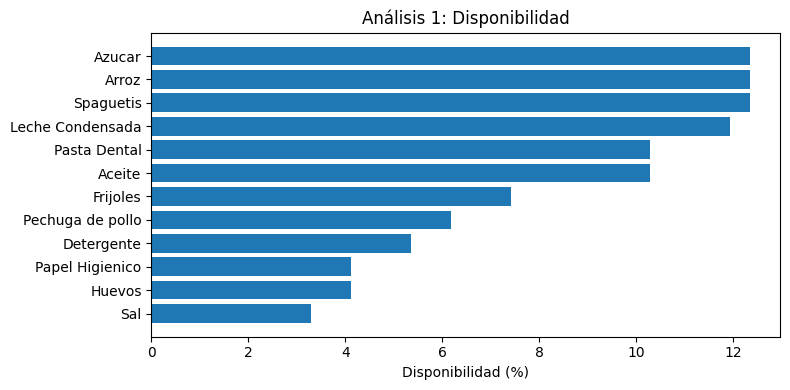

In [1]:
import sys
sys.path.append('../Biblioteca_Funciones')
# 1. Importar funciones
import Funciones as fa
# 2. Cargar y analizar
datos = fa.cargar_datos('../Data/procesados/productos_planos.json')
resultados, total = fa.calcular_disponibilidad(datos)
# 4. Gráfico
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.barh([r[0] for r in resultados], [r[1] for r in resultados])
plt.xlabel('Disponibilidad (%)')
plt.title('Análisis 1: Disponibilidad')
plt.tight_layout()
plt.show()

<h4 style="margin-top: 0; margin-bottom: 0; font-size: 1.3em; font-weight: normal;"> Por tanto, la respuesta a lo que pudiera ser alguna de nuestras preguntas es más que clara en la gráfica: al salir de compras a diferentes MIPYMES en busca de estos 12 productos, nos enfrentaremos a una baja disponibilidad de productos como: <b>sal</b>, <b>huevos</b> o <b>papel higiénico</b>; sin embargo, productos como <b>arroz</b>, <b>azúcar</b> o <b>espaguetis</b> abundan en la mayoría de las MIPYMES de venta de alimentos en La Habana.</h4>

<h2 style="margin-bottom: 0;">Hablemos de precios...</h2> <h4 style="margin-top: 0; margin-bottom: 0; font-size: 1.3em; font-weight: normal;"> Tras analizar las 30 MIPYMES, estos productos, cuando estaban disponibles, presentaban precios bastante elevados, muchos por encima de lo permitido. Estos gráficos muestran los resultados de promediar el precio de cada producto en las MIPYMES de los diferentes municipios, y cuánto varían, en %, los precios de 10 de los 12 productos analizados en las mismas.</h4>

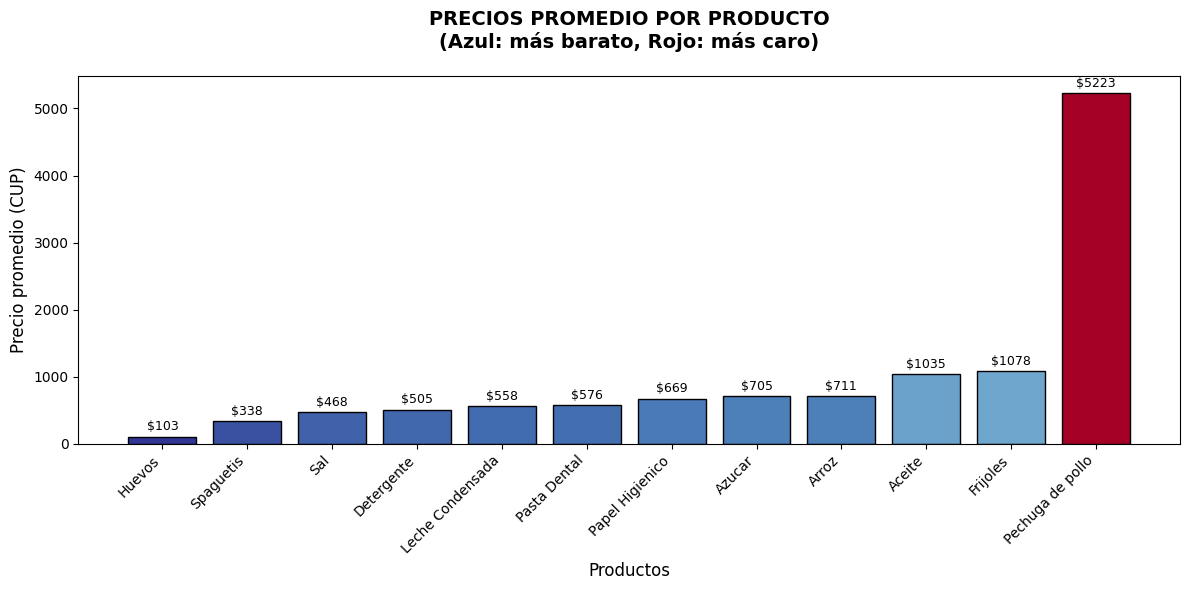

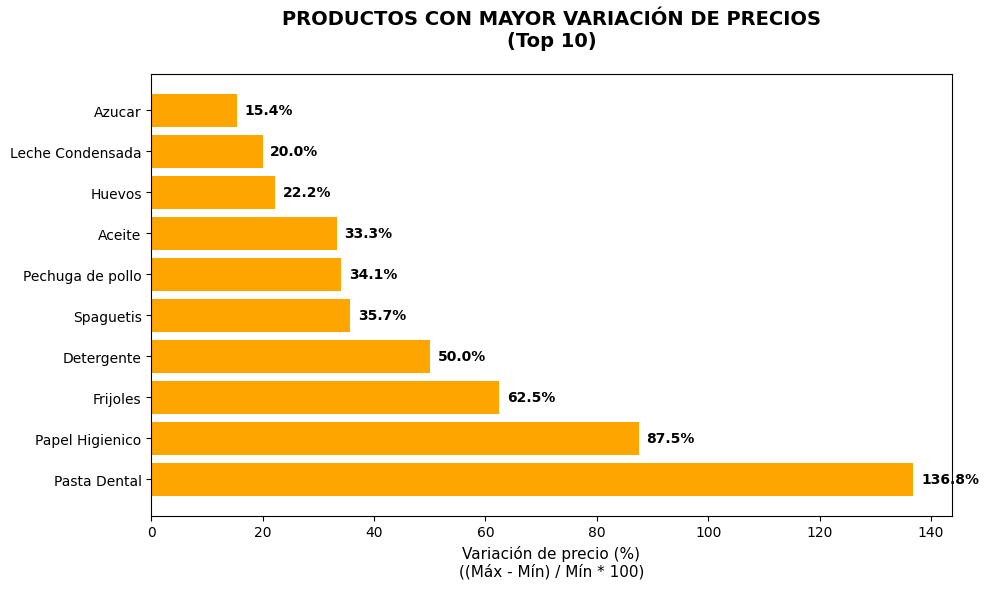

In [1]:
import sys
sys.path.append('../Biblioteca_Funciones')
# Importar funciones de precios
import Funciones as pr


# Cargar datos
datos = pr.cargar_datos('../Data/procesados/productos_planos.json')
precios = pr.calcular_precios(datos)

import matplotlib.pyplot as plt

# GRÁFICO 1: PRECIOS PROMEDIO
plt.figure(figsize=(12, 6))

# Extraer datos
productos = [p['producto'] for p in precios]
promedios = [p['promedio'] for p in precios]

# Crear colores según el precio (azul para barato, rojo para caro)

norm = plt.Normalize(min(promedios), max(promedios))
cmap = plt.cm.RdYlBu_r  # Rojo-Amarillo-Azul (invertido)
colors = [cmap(norm(precio)) for precio in promedios]

# Crear gráfico de barras
bars = plt.bar(productos, promedios, color=colors, edgecolor='black')

# Personalizar
plt.xlabel('Productos', fontsize=12)
plt.ylabel('Precio promedio (CUP)', fontsize=12)
plt.title('PRECIOS PROMEDIO POR PRODUCTO\n(Azul: más barato, Rojo: más caro)',
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')

# Agregar valores en las barras
for bar, promedio in zip(bars, promedios):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + max(promedios)*0.01,
             f'${promedio:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

#Grafico 2
plt.figure(figsize=(10, 6))

# Calcular variaciones
variaciones = pr.calcular_variacion_precios(precios)

# Tomar los 10 con mayor variación
top_variaciones = variaciones[:10]

productos_var = [v['producto'] for v in top_variaciones]
valores_var = [v['variacion'] for v in top_variaciones]

# Gráfico de barras horizontales
bars_h = plt.barh(productos_var, valores_var, color='orange')

plt.xlabel('Variación de precio (%)\n((Máx - Mín) / Mín * 100)', fontsize=11)
plt.title('PRODUCTOS CON MAYOR VARIACIÓN DE PRECIOS\n(Top 10)',
          fontsize=14, fontweight='bold', pad=20)

# Agregar valores
for i, (prod, var) in enumerate(zip(productos_var, valores_var)):
    plt.text(var + max(valores_var)*0.01, i, f'{var:.1f}%',
             va='center', fontweight='bold')

plt.tight_layout()
plt.show()

todos_precios = []
for registro in datos:
    todos_precios.append(registro['precio_cup'])

precio_promedio_general = sum(todos_precios) / len(todos_precios)
precio_min_general = min(todos_precios)
precio_max_general = max(todos_precios)


<h4 style="margin-top: 0; margin-bottom: 0; font-size: 1.3em; font-weight: normal;"> Aunque con precios igualmente caros, los alimentos más "baratos" o accesibles para la familia cubana parecen ser el huevo vendido por unidad y el paquete de espagueti de 500g, estos con un precio promedio de 103 y 330 pesos respectivamente. Aunque el primero presenta una disponibilidad no muy alta, podría, junto con otros alimentos, ser el almuerzo y la comida durante varios días del mes para la familia cubana.
Encabezando el más caro de los productos se encuentra el paquete más pequeño (de 2 kg) de pechuga de pollo que podemos comprar en las MIPYMES. Con un precio promedio de 5223 pesos cubanos, es casi inaccesible para la mayoría de las familias cubanas. El costo de este producto representa más de la mitad de los salarios para muchos en Cuba, los cuales analizaremos próximamente.

Con este análisis también podemos percibir que existen productos que varían mucho su precio en las MIPYMES. Esta variación puede deberse o no a la calidad del producto, pues en casos como la pasta dental o el papel higiénico depende casi en su totalidad de la marca, pero no es tan obvia la razón de una variación tan alta en el precio del kg de frijoles.</h4>

<h2 style="margin-bottom: 0;">¿Cuánto podemos ganar los cubanos mensualmente?</h2>


📊 Fuente: Oficina Nacional de Estadística e Información de Cuba (ONEI)
📅 Fecha: Septiembre 2025
📈 Actividades económicas: 18


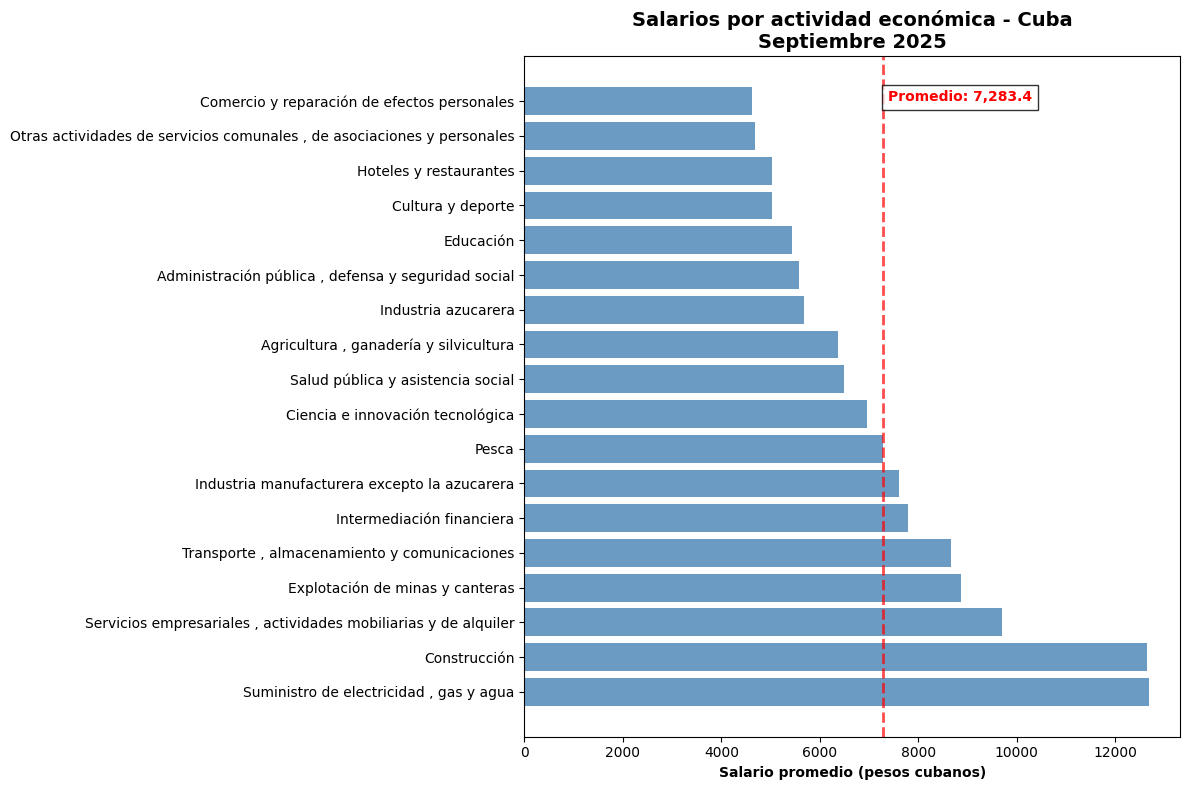

In [4]:
import json
with open('../Data/Procesados/salarios_procesados.json', 'r', encoding='utf-8') as f:
    datos = json.load(f)
print(f"📊 Fuente: {datos['fuente']}")
print(f"📅 Fecha: {datos['fecha_datos']}")
print(f"📈 Actividades económicas: {len(datos['salarios_ordenados'])}")
import matplotlib.pyplot as plt
actividades = list(datos['salarios_ordenados'].keys())
salarios = list(datos['salarios_ordenados'].values())

plt.figure(figsize=(12, 8))
bars = plt.barh(actividades, salarios, color='steelblue', alpha=0.8)

# Personalizar
plt.xlabel('Salario promedio (pesos cubanos)', fontweight='bold')
plt.title(f'Salarios por actividad económica - Cuba\n{datos["fecha_datos"]}', fontsize=14, fontweight='bold')
#Marca linea promedio
promedio = sum(salarios) / len(salarios)
plt.axvline(x=promedio, color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.text(promedio + 100, len(actividades)-1, f'Promedio: {promedio:,.1f}',
         color='red', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))
plt.tight_layout()
plt.show()

<h4 style="margin-top: 0; margin-bottom: 0; font-size: 1.3em; font-weight: normal;"> Está más que claro que lo que podamos llevar a nuestra mesa depende directamente de nuestro salario. A nivel mundial este es quizás uno de los grandes problemas de la humanidad: poder subsistir con un salario que aparentemente es justo. Pero en el siguiente análisis veremos por qué no lo es tanto para nuestro caso en particular, Cuba.</h4>

<h2 style="margin-bottom: 0;">¿Qué tan precarias están las cosas?</h2> <h4 style="margin-top: 0; margin-bottom: 0; font-size: 1.3em; font-weight: normal;"> Llegado a este punto, sería válido preguntarse: ¿cuánto del salario de un cubano podría representar la compra, en pequeñas cantidades, de solo un conjunto de los productos analizados?.</h4>

<h2 style="margin-bottom: 0;">Este análisis muestra cuánto representa comprar:</h2>
<h4 style="margin-top: 0; margin-bottom: 0; font-size: 1.3em; font-weight: normal;">
    <ul style="margin-top: 0; margin-bottom: 0;">
        <li>1 Kg de arroz</li>
        <li>1 Kg de azúcar</li>
        <li>1 Kg de frijoles</li>
        <li>1 Kg de sal</li>
        <li>1 Paquete de espaguetis</li>
        <li>1 Pomo de aceite (1L)</li>
        <li>1 Paquete de detergente</li>
        <li>1 Tubo de pasta dental</li>
    </ul>
</h4>

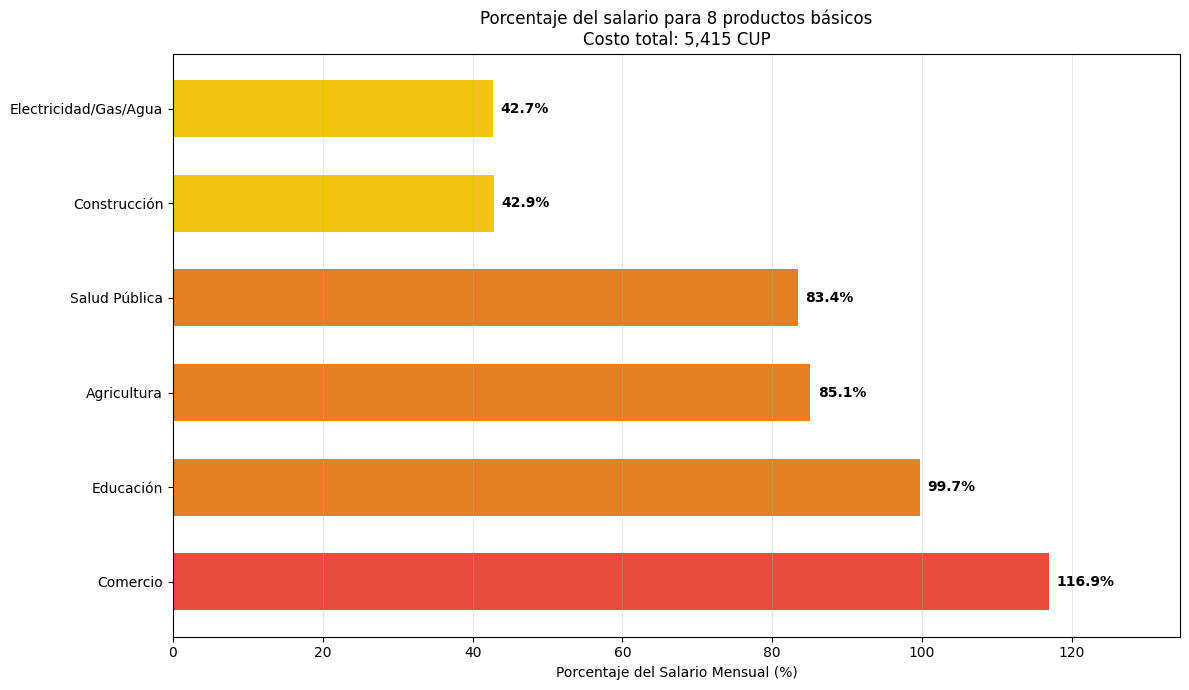

In [5]:
import json
import sys
from matplotlib import pyplot as plt
sys.path.append('../Biblioteca_Funciones')
plt.rcParams['figure.figsize'] = (12, 7)

with open('../Data/Procesados/productos_planos.json', 'r', encoding='utf-8') as f:
    productos = json.load(f)
from Funciones import analizar_asequibilidad

# Ejecutar análisis
resultados, costo_canasta, resumen = analizar_asequibilidad(
    ruta_salarios='../Data/Crudos/salarios_cuba/salarios.json',
    productos=productos
)

sectores = list(resultados.keys())
porcentajes = [resultados[s]['porcentaje'] for s in sectores]

# Ordenar de mayor a menor
datos_ordenados = sorted(zip(sectores, porcentajes), key=lambda x: x[1], reverse=True)
sectores_ordenados = [d[0] for d in datos_ordenados]
porcentajes_ordenados = [d[1] for d in datos_ordenados]

nombres_cortos = []
for sector in sectores_ordenados:
    if sector == "Suministro de electricidad , gas y agua":
        nombres_cortos.append("Electricidad/Gas/Agua")
    elif sector == "Salud pública y asistencia social":
        nombres_cortos.append("Salud Pública")
    elif sector == "Agricultura , ganadería y silvicultura":
        nombres_cortos.append("Agricultura")
    elif sector == "Comercio y reparación de efectos personales":
        nombres_cortos.append("Comercio")
    else:
        nombres_cortos.append(sector)

fig, ax = plt.subplots()

# Colores según porcentaje
colores = []
for p in porcentajes_ordenados:
    if p > 100:
        colores.append('#e74c3c')  # Rojo
    elif p > 50:
        colores.append('#e67e22')  # Naranja
    elif p > 30:
        colores.append('#f1c40f')  # Amarillo
    else:
        colores.append('#2ecc71')  # Verde

# Barras horizontales
bars = ax.barh(nombres_cortos, porcentajes_ordenados, color=colores, height=0.6)

# Añadir valores a las barras
for bar, valor in zip(bars, porcentajes_ordenados):
    ax.text(bar.get_width() + 1,
            bar.get_y() + bar.get_height()/2,
            f'{valor:.1f}%',
            va='center',
            fontsize=10,
            fontweight='bold')

# Configurar gráfico
ax.set_xlabel('Porcentaje del Salario Mensual (%)')
ax.set_title(f'Porcentaje del salario para 8 productos básicos\nCosto total: {costo_canasta:,.0f} CUP')

# Cuadrícula y límites
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, max(porcentajes_ordenados) * 1.15)

# Mostrar gráfico
plt.tight_layout()
plt.show()


<h4 style="margin-top: 0; margin-bottom: 0; font-size: 1.3em; font-weight: normal;"> Como se puede observar, estas cifras son alarmantes, completamente fuera de lo normal. La inflación consume al pueblo cubano lentamente. La compra de este pequeño conjunto de productos representa casi la mitad del salario de una persona que trabaje en el sector de la construcción, mientras que para una persona apasionada por la educación esta compra sería básicamente todo su salario. ¡Insostenible!</h4>

<h4 style="margin-top: 0; margin-bottom: 0; font-size: 1.3em; font-weight: normal;"> A toda esta problemática, hay muchas familias que pueden contar con ayuda del exterior (envío de Dólares/USD), lo cual pudiera representar un gran alivio para cientos de núcleos familiares que, ni juntando sus salarios, pueden "llegar a fin de mes". Esta moneda facilita mucho la compra de cualquier tipo de productos, pues tiendas online como SuperMarket23 o CubaMax son muy populares por su gran variedad de precios y productos de todo tipo,en USD.
El siguiente análisis está basado en la comparación del precio promedio en las MIPYMES de cada producto, con el precio mínimo (llevado a CUP usando la tasa de cambio informal del dólar en Cuba) de cada producto encontrado en las tiendas online, con el objetivo de comparar precios entre estas dos opciones de compra.

</h4>

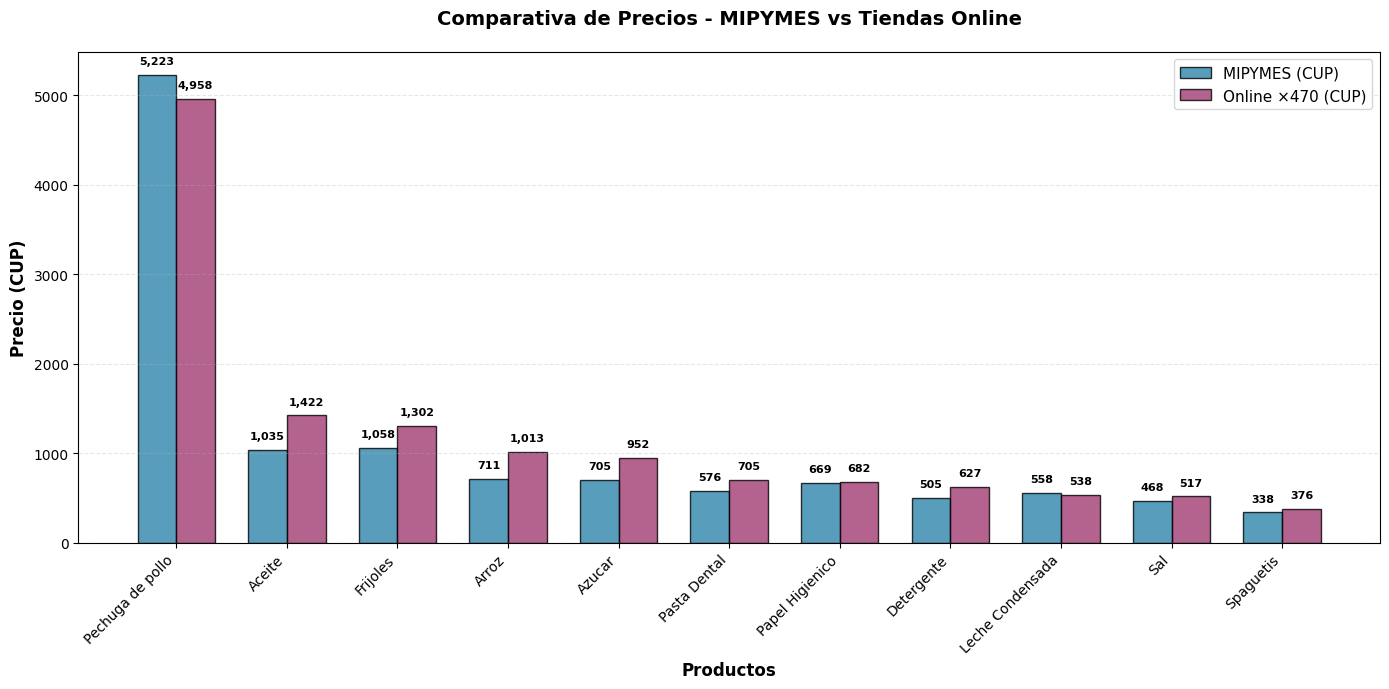

In [6]:
import json
import matplotlib.pyplot as plt
import numpy as np
sys.path.append('../Data/Procesados')

with open('../Data/Procesados/comparativa_resultados.json', 'r', encoding='utf-8') as f:
    comparativa = json.load(f)


# El resto del código funciona IGUAL
diferencias = [p['diferencia'] for p in comparativa]
ratios = [p['ratio'] for p in comparativa]

productos = [p['nombre'] for p in comparativa]
mipyme = [p['mipyme_cup'] for p in comparativa]
online = [p['online_cup'] for p in comparativa]

# Ordenar por precio online para mejor visualización
datos_ordenados = sorted(zip(productos, mipyme, online),
                         key=lambda x: x[2], reverse=True)
productos_ord, mipyme_ord, online_ord = zip(*datos_ordenados)

# Crear gráfico (igual que antes)
x = np.arange(len(productos_ord))
ancho = 0.35

fig, ax = plt.subplots(figsize=(14, 7))

# Barras
barras_m = ax.bar(x - ancho/2, mipyme_ord, ancho,
                  label='MIPYMES (CUP)', color='#2E86AB', alpha=0.8, edgecolor='black')
barras_o = ax.bar(x + ancho/2, online_ord, ancho,
                  label='Online ×470 (CUP)', color='#A23B72', alpha=0.8, edgecolor='black')

# Personalización
ax.set_xlabel('Productos', fontsize=12, fontweight='bold')
ax.set_ylabel('Precio (CUP)', fontsize=12, fontweight='bold')
ax.set_title('Comparativa de Precios - MIPYMES vs Tiendas Online',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(productos_ord, rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Añadir etiquetas
for bar in barras_m:
    height = bar.get_height()
    if height < 50000:
        ax.text(bar.get_x() + bar.get_width()/2, height + 100,
                f'{height:,.0f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold')
for bar in barras_o:
    height = bar.get_height()
    if height < 50000:
        ax.text(bar.get_x() + bar.get_width()/2, height + 100,
                f'{height:,.0f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

<h4 style="margin-top: 0; margin-bottom: 0; font-size: 1.3em; font-weight: normal;">
</h4>

<h4 style="margin-top: 0; margin-bottom: 0; font-size: 1.3em; font-weight: normal;"> Es fácil percibir, al observar el gráfico, que las MIPYMES tienden a tener precios más bajos que las tiendas online en USD, lo cual confirma la imposibilidad de acceder a productos por esta vía para toda persona que no tenga manera de recibir, de cierta forma, los dólares/USD, ya que comprarlos en el mercado informal para luego comprar en tiendas en USD implicaría un gasto aún mayor que el que ya es adquirir en las MIPYMES.</h4>

<h1 style="margin-bottom: 0;">Conclusiones</h1> <h4 style="margin-top: 0; margin-bottom: 0; font-size: 1.3em; font-weight: normal;">
<h4 style="margin-top: 0; margin-bottom: 0; font-size: 1.3em; font-weight: normal;">
Este breve análisis sobre una de las problemáticas más difíciles que vivimos los cubanos deja claro que para muchas familias, alimentarse adecuadamente se ha convertido en un privilegio inalcanzable. La necesidad de cubrir otros gastos obligatorios como transporte, ropa, medicamentos, servicios básicos,fragmenta un presupuesto familiar ya de por sí insuficiente, haciendo prácticamente imposible acceder, siquiera, a los productos más básicos de la canasta alimentaria.
Nos encontramos ante una paradoja dolorosa: mientras las MIPYMES y tiendas online ofrecen una variedad antes inexistente, sus precios las convierten en opciones viables solo para un sector reducido de la población con acceso a divisas. Para la mayoría, dependiente de salarios en pesos cubanos, estos establecimientos son poco más que vitrinas de lo inalcanzable. La brecha entre lo disponible y lo asequible se ensancha día a día, configurando un escenario de abundancia ficticia para unos y escasez crónica para muchos.
</h4>